In [ ]:
#import packages
import numpy as np
import netCDF4 as nc
import xarray as xr
import calendar
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import mapping
import geopandas as gpd
from sklearn.linear_model import TheilSenRegressor
import pymannkendall as mk
import gc
import os

#add path and prepared data

path1='D:/results/'

in_path=path1+"SOM_trans_v4/"

In [ ]:
gph_anom=xr.open_dataarray(in_path+"uyr_gph_anom.nc")
print(gph_anom)
time=gph_anom.time.values
lat=gph_anom.latitude
lon=gph_anom.longitude
lons, lats = np.meshgrid(lon, lat)

shp = gpd.read_file("Upper_Yangtze_River.shp")

def clip_arr(arr):
    arr.rio.write_crs("epsg:4326", inplace=True)
    arr.rio.set_spatial_dims(x_dim="longitude", y_dim="latitude", inplace=True)
    clip_data=arr.rio.clip(shp.geometry, shp.crs, drop=False, all_touched=True)
    return clip_data

clip_da=clip_arr(gph_anom)

#Record grid point coordinate locations
rigional_combo=[]
combo=[] 
da=clip_da[0,:,:]
for j in range(gph_anom.shape[1]):
    for k in range(gph_anom.shape[2]):
        combo.append((j,k))
        if not np.isnan(da[j, k].values):
            rigional_combo.append((j, k))           
#print(rigional_combo) #len=1674

indices = []
for item in rigional_combo:
    idx = combo.index(item)
    indices.append(idx)
print(indices)   #len=1674

gc.collect()

In [ ]:
#Seasonally separated indices facilitate subsequent processing

gph_anom['time'] = pd.to_datetime(gph_anom.time.values)

def get_season_indices(data_array):
    month = data_array.time.dt.month

    seasons = {
        'Spring': [3, 4, 5],
        'Summer': [6, 7, 8],
        'Autumn': [9, 10, 11],
        'Winter': [12, 1, 2]
    }
    
    season_ind = {}
    for season, months in seasons.items():
        
        mask = month.isin(months)
        
        season_ind[season] = np.where(mask)[0]
        
        print(f"{season}: {len(season_ind[season])} days")
        
    return season_ind

# get indices
season_ind = get_season_indices(gph_anom)

for season in season_ind:
    print(f"{season} : {season_ind[season]}")

gc.collect()

Spring: 4048 days
Summer: 4048 days
Autumn: 4004 days
Winter: 3960 days
Spring : [   59    60    61 ... 15843 15844 15845]
Summer : [  151   152   153 ... 15935 15936 15937]
Autumn : [  243   244   245 ... 16026 16027 16028]
Winter : [    0     1     2 ... 16057 16058 16059]


43

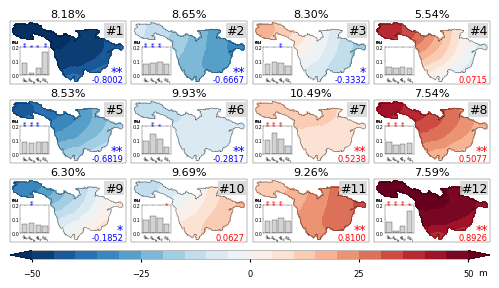

In [ ]:
#gph pattern total  4x3

from matplotlib.colors import TwoSlopeNorm
import cartopy.crs as ccrs
# pattern+feature

som_grids = {'grid3x4': (3, 4)}   

seasons=('Spring','Summer','Autumn','Winter')

years = np.arange(1979, 2023)

for grid_name, grid_size in som_grids.items():
    
    input_combo=[]  
    for j in range(grid_size[0]):
        for k in range(grid_size[1]):                 
                input_combo.append((j,k))   
    #print(len(input_combo))
    
    feature=pd.read_excel(in_path+"feature/gph_node_"+grid_name+"_total.xlsx")
    feature_spring=pd.read_excel(in_path+"feature/gph_node_"+grid_name+"_Spring.xlsx")
    feature_summer=pd.read_excel(in_path+"feature/gph_node_"+grid_name+"_Summer.xlsx")
    feature_autumn=pd.read_excel(in_path+"feature/gph_node_"+grid_name+"_Autumn.xlsx")
    feature_winter=pd.read_excel(in_path+"feature/gph_node_"+grid_name+"_Winter.xlsx")

    sum_occur=np.sum(feature['occur'])
    sum_spring=np.sum(feature_spring['occur'])
    sum_summer=np.sum(feature_summer['occur'])
    sum_autumn=np.sum(feature_autumn['occur'])
    sum_winter=np.sum(feature_winter['occur'])

    pattern=pd.read_csv(in_path+"som_results/gph_"+grid_name+"_total_weights.csv")  #pd.DataFrame
    
    weights_nan=np.full((grid_size[0]*grid_size[1],len(lon.values)*len(lat.values)),np.nan)
    
    for i in range(len(indices)):
        loc=indices[i]
        weights_nan[:,loc]=np.array(pattern)[:,i]

    weights = weights_nan.reshape(grid_size[0], grid_size[1], len(lon.values)*len(lat.values))# numpy.ndarray (n, n, len(lon.values)*len(lat.values))

    fig, axs = plt.subplots(grid_size[0], grid_size[1], subplot_kw=dict(projection=ccrs.PlateCarree()), figsize=(12, 8))
    
    for n in range(len(input_combo)):
        num_spring=feature_spring['occur'][n]
        num_summer=feature_summer['occur'][n]
        num_autumn=feature_autumn['occur'][n]
        num_winter=feature_winter['occur'][n]
        
        (i, j) = input_combo[n]
        node=weights[i, j, :].reshape(len(lat), len(lon))  
        node_data=xr.DataArray(node, dims=('latitude','longitude'), coords=({'longitude':lon,'latitude':lat}))
        node_da=clip_arr(node_data)
        levels = np.arange(-50, 51, 5)
        ax=axs[i,j]
        #ax.coastlines(linewidth=0.2, alpha=1)
        
        ax.set_extent([90, 112, 36, 24], crs=ccrs.PlateCarree())
        cf = ax.contourf(lons, lats, node_da, transform=ccrs.PlateCarree(), levels=levels, extend='both', cmap="RdBu_r", norm = TwoSlopeNorm(vcenter=0))
        #cc = ax.contour(lons, lats, node_da, transform=ccrs.PlateCarree(), levels=levels, colors='black', linewidths=0.2)
        ax.annotate(f'#{n+1}', xy=(0.98, 0.8), xycoords='axes fraction',horizontalalignment='right',fontsize=9,color='black',bbox=dict(facecolor='lightgrey', edgecolor='None', alpha=0.8, pad=0.5))
        ax.add_geometries(shp.geometry, crs=ccrs.PlateCarree(), facecolor='none', edgecolor='black', alpha=1, linewidth=0.2)
    
        for spine in ax.spines.values():
            spine.set_linewidth(0.2)

        occur_spring=num_spring/sum_spring
        occur_summer=num_summer/sum_summer
        occur_autumn=num_autumn/sum_autumn
        occur_winter=num_winter/sum_winter
        sum_n=(num_spring+num_summer+num_autumn+num_winter)/sum_occur
        #print(n,sum_n,occur_spring,occur_summer,occur_autumn,occur_winter)

        ax.set_title(f'{sum_n:.2%}', loc='center', fontsize=8, color='black', pad=3)
        
        '''
        ax.annotate(f'{occur_spring:.2%}', xy=(0.33, 0.53), xycoords='axes fraction',horizontalalignment='right',fontsize=7.5,color='black')
        ax.annotate(f'{occur_summer:.2%}', xy=(0.33, 0.36), xycoords='axes fraction',horizontalalignment='right',fontsize=7.5,color='black')
        ax.annotate(f'{occur_autumn:.2%}', xy=(0.33, 0.19), xycoords='axes fraction',horizontalalignment='right',fontsize=7.5,color='black')
        ax.annotate(f'{occur_winter:.2%}', xy=(0.33, 0.02), xycoords='axes fraction',horizontalalignment='right',fontsize=7.5,color='black')
        '''
        mk_result_per_p=feature['mk_result_per_p'][n]
        slope_per=feature['slope_per'][n]

        if slope_per<0:
            color='blue'
        else:
            color='red'
        
        if mk_result_per_p<0.01:
            text='**'
        elif mk_result_per_p<0.05:
            text='*'
        else:
            text=''
            
        ax.annotate(f'{slope_per:.4f}', xy=(0.98, 0.04), xycoords='axes fraction',horizontalalignment='right',fontsize=6,color=color)
        ax.annotate(text, xy=(0.98, 0.14), xycoords='axes fraction',horizontalalignment='right',fontsize=9,color=color)

        bar_data=np.array([occur_spring,occur_summer,occur_autumn,occur_winter])

        axin=ax.inset_axes([0.09,0.14,0.25,0.45])
        bars=axin.bar(np.arange(1,5),bar_data,width=0.8,edgecolor='black',facecolor='lightgrey',linewidth=0.2)

        axin.set_xticks(np.arange(1,4.1,1))
        axin.set_xticklabels(['Spr', 'Sum', 'Aut', 'Win'])
        axin.tick_params(axis='x', rotation=-30)
        axin.set_xlim([0.4,4+0.6])
        axin.set_yticks(np.arange(0,0.25,0.1))
        axin.xaxis.set_ticks_position('both')
        axin.tick_params(axis='y', direction='in',length=1,width=0.2,labelsize=3.5,pad=1)
        axin.tick_params(axis='x', direction='in',length=1,width=0.2, labelsize=3, pad=0.5)

        for spine in axin.spines.values():
            spine.set_linewidth(0.2)

        for s in np.arange(4):
            season=seasons[s]
            feature_season=pd.read_excel(in_path+"feature/gph_node_"+grid_name+f"_{season}_v3.xlsx")
            mk_result_per_p_s=feature_season['mk_result_per_p'][n]
            slope_per_s=feature_season['slope_per'][n]

            if slope_per_s<0:
                color_s='blue'
            else:
                color_s='red'
            
            if mk_result_per_p_s<0.01:
                text_s='**'
            elif mk_result_per_p_s<0.05:
                text_s='*'
            else:
                text_s=''

            if s==0:
                xy=(0.307, 1.04)
            elif s==1:
                xy=(0.545, 1.04)
            elif s==2:
                xy=(0.7835, 1.04)
            else:
                xy=(1.03, 1.04)
    
            axin.annotate(text_s, xy=xy, xycoords='axes fraction',horizontalalignment='right',fontsize=4.5,color=color_s,rotation=90, verticalalignment='bottom')
            axin.annotate('(%)', xy=(-0.05,1.15), xycoords='axes fraction',horizontalalignment='right',fontsize=3,color='black')


    plt.subplots_adjust(left=0.3, right=0.7, top=0.7, bottom=0.35) 
    fig.subplots_adjust(wspace=0.05, hspace=0.1)

    cbar = fig.colorbar(cf, ax=axs[:,:], orientation='horizontal', aspect=55, pad=0.03)
    cbar.set_ticks(np.arange(-50, 51, 25))
    cbar.outline.set_linewidth(0.2)
    cbar.ax.tick_params(labelsize=6, length=2, pad=5)
    fig.text(0.69,0.372,'m',size=6.5)

    output_dir = in_path+' '
    os.makedirs(output_dir, exist_ok=True)
    fig.savefig(output_dir+"gph_"+grid_name+"_total_pattern.png",dpi=1000,bbox_inches='tight')
    
    plt.show()